# CICLe on SST-5

Model: **Mistral-7B-v0.3** | Embedding: **tfidf** | Base classifier: **logistic regression** | shots: **1** | variant: **fixed** | alpha: **0.05**

CICLe combines a conformal base classifier with in-context learning: the base classifier proposes a (small) set of candidate classes that is guaranteed to contain the true class with probability 0.95, and an LLM is then prompted with a few examples to pick the final label from that set.

### Prerequisites:

Before we dive into the implementation, we have to install some prerequisites:

 - we use [pandas](https://pandas.pydata.org/docs/) to easily load and format our data
 - we use the [crepes](https://github.com/henrikbostrom/crepes) library together with [scikit-learn](https://scikit-learn.org/stable/api/index.html) to implement our conformal base classifier
 - we use Mistral-7B-v0.3 for prompting

Furthermore, we will perform our experiments on the [SST-5 dataset](https://huggingface.co/datasets/SetFit/sst5).

In [1]:
%%capture
# install dependencies:
!pip install numpy matplotlib seaborn torch pandas scikit-learn crepes transformers sentence-transformers accelerate tqdm datasets

### Data processing

In [2]:
from datasets import load_dataset

train_data = load_dataset("SetFit/sst5", split="train")
test_data = load_dataset("SetFit/sst5", split="test")

print(f"Train set size: {len(train_data)} examples")
print(f"Test set size: {len(test_data)} examples")

Repo card metadata block was not found. Setting CardData to empty.


Repo card metadata block was not found. Setting CardData to empty.


Train set size: 8544 examples
Test set size: 2210 examples


In [3]:
# convert datasets to dataframes:
train_df = train_data.to_pandas()
test_df = test_data.to_pandas()

# filter out empty texts:
train_df = train_df[train_df['text'].str.strip().astype(bool)]
test_df = test_df[test_df['text'].str.strip().astype(bool)]

train_df.sample()

,text,label,label_text
1227,"if you 're paying attention , the `` big twist...",2,neutral


In [4]:
from sklearn.model_selection import train_test_split

# sample 2k training examples stratified by label:
train_df, _ = train_test_split(
    train_df, stratify=train_df["label"], train_size=2000, random_state=42
)

# sample 1k test examples stratified by label:
test_df, _ = train_test_split(
    test_df, stratify=test_df["label"], train_size=1000, random_state=42
)

# create the development set:
train_df, dev_df = train_test_split(
    train_df, stratify=train_df["label"], test_size=0.2, shuffle=True, random_state=42
)

print(f"Train subset size: {len(train_df)} examples")
print(f"Dev subset size: {len(dev_df)} examples")
print(f"Test subset size: {len(test_df)} examples")

Train subset size: 1600 examples
Dev subset size: 400 examples
Test subset size: 1000 examples


We use the sentiment category (`label_text`) associated with each review `text` as the target category to predict:

In [5]:
# use the sentiment name as the target label:
train_df['label_name'] = train_df['label_text']
dev_df['label_name'] = dev_df['label_text']
test_df['label_name'] = test_df['label_text']

In [6]:
# select input and label from data:
X_train = train_df['text'].to_numpy()
y_train = train_df['label_name'].to_numpy()

X_dev = dev_df['text'].to_numpy()
y_dev = dev_df['label_name'].to_numpy()

X_test = test_df['text'].to_numpy()
y_test = test_df['label_name'].to_numpy()

classes = set(y_train)
print('Classes: ', len(classes))

Classes:  5


### Train base classifier

We import `TfidfVectorizer` from `sklearn.feature_extraction.text` and fit it on `X_train`. We define a utility function (`phi`) that converts the resulting sparse matrix into a dense array using `.toarray()`, since `crepes` does not handle sparse matrices well.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# create and train input embedding:
tfidf = TfidfVectorizer().fit(X_train)

# since TfidfVectorizer.transform(...) returns a sparse matrix which 'crepes'
# does not handle well, we use the following utility function to encode our texts:
def phi(texts, batch_size=None):
    return tfidf.transform(texts).toarray()

# test embedding shape
phi(X_train[:2]).shape

(2, 6207)

Now let's create a list of unique labels (`id2label`) from the training labels `y_train`. We then build a dictionary (`label2id`) that maps each label to a unique ID using enumeration.

In [8]:
import numpy as np

# create label to one-hot and reverse dictionaries:
id2label = np.unique(y_train)
label2id = {l: i for i, l in enumerate(id2label)}

# show label-id mapping:
label2id

{'negative': 0,
 'neutral': 1,
 'positive': 2,
 'very negative': 3,
 'very positive': 4}

Now let's train our conformal base classifier! We use the `WrapClassifier` class from `crepes` wrapping logistic regression. We train it on `phi(X_train)` and calibrate it on `phi(X_dev)` using class-conditional calibration (`class_cond=True`).

In [9]:
from crepes import WrapClassifier
from sklearn.linear_model import LogisticRegression

# create a conformal base classifier based on Logistic Regression:
base_classifier = WrapClassifier(LogisticRegression(max_iter=1000))

# train the base classifier:
X_train_emb = phi(X_train)
base_classifier.fit(
    X_train_emb,
    [label2id[y] for y in y_train]
)

# calibrate the base classifier:
base_classifier.calibrate(
    phi(X_dev),
    [label2id[y] for y in y_dev],
    class_cond=True
)

WrapClassifier(learner=LogisticRegression(max_iter=1000), calibrated=True, predictor=ConformalClassifier(fitted=True, mondrian=True))

In [10]:
# pre-compute test embeddings before loading LLM:
print("Pre-computing test embeddings...")
X_test_emb = phi(X_test)
print(f"X_train_emb: {X_train_emb.shape}, X_test_emb: {X_test_emb.shape}")

Pre-computing test embeddings...
X_train_emb: (1600, 6207), X_test_emb: (1000, 6207)


### Instantiate Mistral-7B-v0.3

In order to be able to use huggingface's Mistral-7B-v0.3 model, we first need to log in to huggingface (you may need to request access depending on the model).

In [11]:
# import getpass
# from huggingface_hub import login
# login(getpass.getpass('Enter your huggingface API-key:'))

In this tutorial we will use the standard huggingface text-generation pipeline (compressed to 16 bit floating point weights) for Mistral-7B-v0.3.

In [12]:
import transformers
import torch

# create llm pipeline:
llm = transformers.pipeline(
    "text-generation",
    model="mistralai/Mistral-7B-Instruct-v0.3",
    model_kwargs={"torch_dtype": torch.bfloat16},
    device_map="auto"
)

# Get special tokens for later:
bos_token_id = llm.tokenizer.bos_token_id
eos_token_id = llm.tokenizer.eos_token_id
pad_token_id = llm.tokenizer.pad_token_id or llm.tokenizer.eos_token_id

`torch_dtype` is deprecated! Use `dtype` instead!


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

### Results Handling Helper

In [13]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import json
import numpy as np

def save_results(y_true, y_pred, classes, filename="results.json", set_sizes=None):
    """
    Save classification metrics (report, accuracy, confusion matrix) to JSON.
    set_sizes, if given, is the per-test-example conformal prediction set size
    (len(ps)), used to analyse the effect of the conformal filter on CICLe.
    """
    report = classification_report(
        y_true, y_pred, labels=classes, zero_division=0, output_dict=True
    )
    accuracy = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=classes)

    results = {
        "classification_report": report,
        "accuracy": accuracy,
        "confusion_matrix": cm.tolist(),
        "labels": classes
    }

    if set_sizes is not None:
        set_sizes = [int(s) for s in set_sizes]
        results["conformal_set_sizes"] = {
            "values": set_sizes,
            "n_empty": sum(1 for s in set_sizes if s == 0),
            "n_singleton": sum(1 for s in set_sizes if s == 1),
            "n_llm": sum(1 for s in set_sizes if s > 1),
            "mean": float(np.mean(set_sizes)),
        }

    with open(filename, "w") as f:
        json.dump(results, f, indent=2)

    print(f"Results saved to: '{filename}'")

In [14]:
import json
import numpy as np

def save_prompt_lengths(prompt_lengths, input_lengths, shots_lengths, num_shots, filename="prompt_lengths.json"):
    """
    Save prompt, input, shots section lengths, and number of shots to a JSON file,
    including summary statistics.
    """
    stats = {
        "prompt_lengths": {
            "mean": float(np.mean(prompt_lengths)),
            "min": int(np.min(prompt_lengths)),
            "max": int(np.max(prompt_lengths)),
            "std": float(np.std(prompt_lengths)),
            "values": prompt_lengths
        },
        "input_lengths": {
            "mean": float(np.mean(input_lengths)),
            "min": int(np.min(input_lengths)),
            "max": int(np.max(input_lengths)),
            "std": float(np.std(input_lengths)),
            "values": input_lengths
        },
        "shots_lengths": {
            "mean": float(np.mean(shots_lengths)),
            "min": int(np.min(shots_lengths)),
            "max": int(np.max(shots_lengths)),
            "std": float(np.std(shots_lengths)),
            "values": shots_lengths
        },
        "num_shots": {
            "mean": float(np.mean(num_shots)),
            "min": int(np.min(num_shots)),
            "max": int(np.max(num_shots)),
            "std": float(np.std(num_shots)),
            "values": num_shots
        }
    }

    with open(filename, "w") as f:
        json.dump(stats, f, indent=2)

    print(f"Prompt length statistics saved to: '{filename}'")

### CICLe

`get_fixed_k_examples` returns the globally `k` most similar training examples (from classes in the conformal prediction set) for a given test example, selected by cosine similarity over the precomputed embeddings.

In [15]:
from sklearn.metrics import pairwise_distances

def get_fixed_k_examples(test_idx, prediction_set, k=2):
    """
    Return exactly k training examples with highest cosine similarity to X_test[test_idx],
    selected globally from classes in the prediction_set.
    Returns list of (text, label, similarity) tuples sorted by descending similarity.
    """
    test_emb = X_test_emb[test_idx:test_idx+1]
    mask = np.isin(y_train, list(prediction_set))
    if not mask.any():
        return []
    train_embs_masked = X_train_emb[mask]
    y_train_masked = y_train[mask]
    X_train_masked = X_train[mask]
    similarity = (1. - pairwise_distances(test_emb, train_embs_masked, metric='cosine'))[0]
    top_k_idx = np.argsort(similarity)[::-1][:k]
    return [(X_train_masked[i], y_train_masked[i], similarity[i]) for i in top_k_idx]

In [16]:
# print sample output:
samples = get_fixed_k_examples(
    0,
    id2label[base_classifier.predict_set(X_test_emb[:1], confidence=0.95).astype(bool)[0]],
    k=2
)
samples

[("it 's an ambitious film , and as with all ambitious films , it has some problems .",
  'positive',
  np.float64(0.264504264304835)),
 ("an ambitious ` what if ? '", 'positive', np.float64(0.25038168292713814))]

In [17]:
def create_prompt(text, examples):
    # helper function replacing quotation marks in the text:
    replace_qm = lambda s: s.replace('"', "'")

    # create context:
    context = f'We classify movie review snippets into sentiment categories based on their text. Here are some labelled examples sorted from most probable to least probable:\n'

    for x, y, _ in examples:
        context += f'\n"{replace_qm(x)}" => {y}'

    return {"role": "user", "content": f'{context}\n\nPlease predict the correct class for the following sample. Only provide the class label.\n\n"{replace_qm(text)}" => '}

# print sample prompt:
print(create_prompt(X_test[0], [(X_train[0], y_train[0], 1.0)])["content"])

We classify movie review snippets into sentiment categories based on their text. Here are some labelled examples sorted from most probable to least probable:

"-lrb- taylor -rrb- takes us on a ride that 's consistently surprising , easy to watch -- but , oh , so dumb ." => neutral

Please predict the correct class for the following sample. Only provide the class label.

"though the book runs only about 300 pages , it is so densely packed ... that even an ambitious adaptation and elaborate production like mr. schepisi 's seems skimpy and unclear ." => 


Now it's time to calculate the conformal prediction sets for our test data:

In [18]:
# calculate prediction sets:
ps_test = [id2label[s.astype(bool)] for s in base_classifier.predict_set(X_test_emb, confidence=0.95)]

Finally, we put all pieces together to predict labels for the test set using CICLe. For each text and its associated prediction set, `get_fixed_k_examples` retrieves the 1 most similar training examples. If the prediction set contains only one class, that class is directly used as the prediction.

In [19]:
from tqdm import tqdm

# predict test set:
predictions = []
set_sizes = []
for i, (x, ps) in tqdm(enumerate(zip(X_test, ps_test)), total=len(X_test), desc='Assessing texts'):
    set_sizes.append(len(ps))
    if len(ps) > 1:
        # get 1 most similar texts in the training data:
        examples = get_fixed_k_examples(i, ps, k=1)

        # create prompt:
        prompt = create_prompt(x, examples)

        # prompt LLM:
        predictions.append(llm([prompt],
            bos_token_id=bos_token_id,
            eos_token_id=eos_token_id,
            pad_token_id=pad_token_id,
            max_new_tokens=5,
            do_sample=False,
            temperature=None,
            top_p=None
        )[0]["generated_text"][-1]["content"])

    elif len(ps) == 1:
        predictions.append(ps[0])
    else:
        predictions.append(id2label[base_classifier.predict(X_test_emb[i:i+1])[0]])

Assessing texts:   0%|          | 0/1000 [00:00<?, ?it/s]

Passing `generation_config` together with generation-related arguments=({'top_p', 'pad_token_id', 'temperature', 'do_sample', 'max_new_tokens', 'bos_token_id', 'eos_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Assessing texts:   0%|          | 1/1000 [00:00<11:01,  1.51it/s]

Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Assessing texts: 100%|█████████▉| 999/1000 [03:41<00:00,  4.54it/s]

Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Assessing texts: 100%|██████████| 1000/1000 [03:41<00:00,  4.70it/s]

Assessing texts: 100%|██████████| 1000/1000 [03:41<00:00,  4.51it/s]

Classification Report:
                precision    recall  f1-score   support

     positive       0.00      0.00      0.00       231
very positive       0.00      0.00      0.00       181
very negative       0.00      0.00      0.00       126
     negative       1.00      0.00      0.01       286
      neutral       0.00      0.00      0.00       176

    micro avg       0.50      0.00      0.00      1000
    macro avg       0.20      0.00      0.00      1000
 weighted avg       0.29      0.00      0.00      1000

Accuracy: 0.001


(array([0.5, 1.5, 2.5, 3.5, 4.5]),
 [Text(0, 0.5, 'positive'),
  Text(0, 1.5, 'very positive'),
  Text(0, 2.5, 'very negative'),
  Text(0, 3.5, 'negative'),
  Text(0, 4.5, 'neutral')])

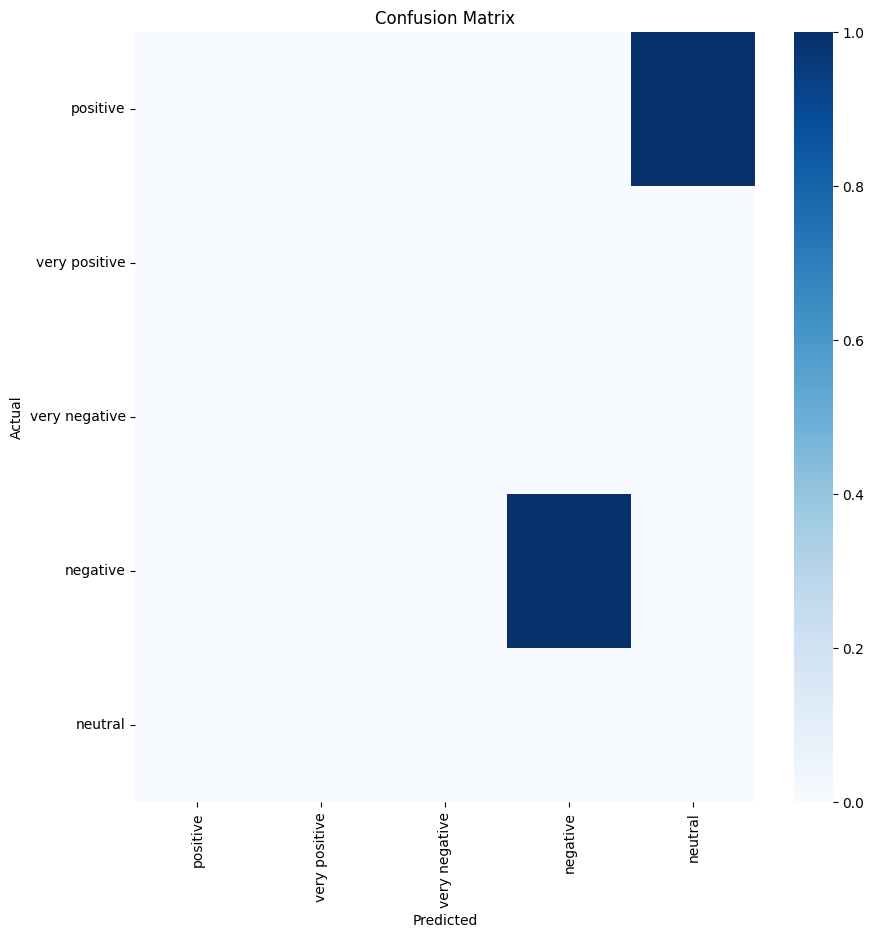

In [20]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Classification Report:\n", classification_report(y_test, predictions, labels=list(classes), zero_division=0))
print("Accuracy:", accuracy_score(y_test, predictions))

# Plot confusion matrix
cm = confusion_matrix(y_test, predictions, labels=list(classes))
plt.figure(figsize=(10, 10))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=list(classes), yticklabels=list(classes))
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.xticks(rotation=90); plt.yticks(rotation=0)

In [21]:
from tqdm import tqdm
import numpy as np

prompt_lengths = []
input_lengths = []
shots_lengths = []
num_shots = []

for i, (x, ps) in tqdm(enumerate(zip(X_test, ps_test)), total=len(X_test), desc='Calculating token stats'):
    if len(ps) > 1:
        # get the most similar examples
        examples = get_fixed_k_examples(i, ps, k=1)

        # build the prompt (same as before)
        prompt = create_prompt(x, examples)["content"]

        # compute tokenized lengths
        prompt_len = len(llm.tokenizer(prompt)["input_ids"])
        input_len = len(llm.tokenizer(x)["input_ids"])
        # join the examples' text parts for shots length
        shots_text = "\n".join([ex[0] if isinstance(ex, (list, tuple)) else str(ex) for ex in examples])
        shots_len = len(llm.tokenizer(shots_text)["input_ids"])

        prompt_lengths.append(prompt_len)
        input_lengths.append(input_len)
        shots_lengths.append(shots_len)
        num_shots.append(len(examples))

# Print averages
print(f"Average prompt length: {np.mean(prompt_lengths):.1f} tokens")
print(f"Average input length: {np.mean(input_lengths):.1f} tokens")
print(f"Average shots section length: {np.mean(shots_lengths):.1f} tokens")
print(f"Average number of shots: {np.mean(num_shots):.1f}")

Calculating token stats:   0%|          | 0/1000 [00:00<?, ?it/s]

Calculating token stats:   0%|          | 1/1000 [00:00<02:21,  7.06it/s]

Calculating token stats:   0%|          | 2/1000 [00:00<02:16,  7.32it/s]

Calculating token stats:   0%|          | 3/1000 [00:00<02:35,  6.40it/s]

Calculating token stats:   0%|          | 4/1000 [00:00<03:00,  5.53it/s]

...

Calculating token stats: 100%|█████████▉| 998/1000 [03:02<00:00,  4.60it/s]

Calculating token stats: 100%|█████████▉| 999/1000 [03:03<00:00,  4.78it/s]

Calculating token stats: 100%|██████████| 1000/1000 [03:03<00:00,  4.25it/s]

Calculating token stats: 100%|██████████| 1000/1000 [03:03<00:00,  5.45it/s]

Average prompt length: 102.4 tokens
Average input length: 26.0 tokens
Average shots section length: 18.7 tokens
Average number of shots: 1.0


In [22]:
save_results(y_test, predictions, list(classes), filename="/home/v25/ippa6201/cicle-evaluation/sst/results/predictions/sst-mistral-7b-v0.3-cicle-tfidf-lr-2.0k-samples-1-shots-fixed-0.05-α.json", set_sizes=set_sizes)

Results saved to: '/home/v25/ippa6201/cicle-evaluation/sst/results/predictions/sst-mistral-7b-v0.3-cicle-tfidf-lr-2.0k-samples-1-shots-fixed-0.05-α.json'


In [23]:
save_prompt_lengths(prompt_lengths, input_lengths, shots_lengths, num_shots, filename="/home/v25/ippa6201/cicle-evaluation/sst/results/lengths/sst-mistral-7b-v0.3-cicle-tfidf-lr-2.0k-samples-1-shots-fixed-0.05-α.json")

Prompt length statistics saved to: '/home/v25/ippa6201/cicle-evaluation/sst/results/lengths/sst-mistral-7b-v0.3-cicle-tfidf-lr-2.0k-samples-1-shots-fixed-0.05-α.json'
